<!-- STANDIN notebook title -->
# Part notebook: supervised models and their explanations (steps A4–A6, B1, B2, B5, B6, C1, C2)

Owner: Kirill. This title and the stand-in cells are dropped by `tools/assemble.py`.

In [1]:
# STANDIN A1-A3
%run 00_setup.ipynb

(11430, 89)
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


6858 2286 2286
train      phishing share: 0.500
validation phishing share: 0.500
test       phishing share: 0.500


<!-- STEP A4 -->
### 5.1 Supervised: all labels

## Step A4: Glass box 1: a small decision tree

We try depth 3 and 4 and keep the better one on the **validation** set (never on test). We read the
tree in step B1.

In [2]:
# STEP A4
from sklearn.tree import DecisionTreeClassifier, export_text

best_score, tree = -1, None
depth_scores = []                                  # both depths, for the report
for depth in [3, 4]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    scores = report(t, X_val, y_val)
    score = scores["macro_F1"]                     # choose on VALIDATION
    print("depth", depth, "validation macro-F1:", round(score, 3))
    depth_scores.append({"max_depth": depth, "leaves": t.get_n_leaves(), **scores})
    if score > best_score:
        best_score, tree = score, t
print("kept depth", tree.get_depth())

depth_scores = pd.DataFrame(depth_scores)
depth_scores.to_csv("results/tables/A4_tree_depth.csv", index=False)
depth_scores

depth 3 validation macro-F1: 0.913


depth 4 validation macro-F1: 0.925
kept depth 4


,max_depth,leaves,macro_F1,recall,ROC_AUC,FAR
0,3,8,0.913,0.904,0.948,0.079
1,4,16,0.925,0.920,0.954,0.070


<!-- STEP A5 -->
## Step A5: Glass box 2: logistic regression

One weight per feature. We scale the features first so the weights can be compared; the `Pipeline`
fits the scaler on training data only.

In [3]:
# STEP A5
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# The Pipeline fits the scaler on training data only. No leakage.
logreg = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train, y_train)
print(report(logreg, X_val, y_val))

{'macro_F1': 0.938, 'recall': 0.933, 'ROC_AUC': 0.983, 'FAR': 0.056}


<!-- STEP A6 -->
## Step A6: The black box: a Random Forest

300 trees trained on all labels. This is the **upper line**: the best we can hope for when every URL
is labelled.

In [4]:
# STEP A6
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(report(rf, X_val, y_val))

{'macro_F1': 0.961, 'recall': 0.968, 'ROC_AUC': 0.993, 'FAR': 0.046}


<!-- STEP B1 -->
# 6. Part B: Explain the detectors

## Step B1: Read the glass boxes

The tree and the logistic regression need no SHAP or LIME: the model itself is the explanation.
In the tree, each `|---` line is a yes/no question and `class: 1` means phishing. In the logistic
regression, a positive weight pushes toward phishing (the features are scaled, so the weights can be
compared).

In [5]:
# STEP B1
# Glass box 1: the tree, printed as rules
tree_rules = export_text(tree, feature_names=list(X_train.columns))
print(tree_rules)
print("tree leaves:", tree.get_n_leaves())
with open("results/tables/B1_tree_rules.txt", "w") as f:
    f.write(tree_rules)

# Glass box 2: one weight per feature. Positive = pushes toward phishing.
w = pd.Series(logreg.named_steps["lr"].coef_[0], index=X_train.columns)
top10 = w.abs().sort_values(ascending=False).index[:10]
print(w[top10].round(3))
print("logreg weights with |w| > 0.01:", int((w.abs() > 0.01).sum()))
w[top10].round(3).rename("weight").to_csv("results/tables/B1_logreg_top10_weights.csv")

|--- google_index <= 0.50
|   |--- page_rank <= 0.50
|   |   |--- shortest_word_path <= 0.50
|   |   |   |--- nb_www <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_www >  0.50
|   |   |   |   |--- class: 0
|   |   |--- shortest_word_path >  0.50
|   |   |   |--- nb_hyphens <= 4.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyphens >  4.50
|   |   |   |   |--- class: 0
|   |--- page_rank >  0.50
|   |   |--- nb_qm <= 0.50
|   |   |   |--- phish_hints <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- phish_hints >  1.50
|   |   |   |   |--- class: 1
|   |   |--- nb_qm >  0.50
|   |   |   |--- nb_hyperlinks <= 32.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyperlinks >  32.50
|   |   |   |   |--- class: 0
|--- google_index >  0.50
|   |--- page_rank <= 2.50
|   |   |--- domain_in_brand <= 0.50
|   |   |   |--- ratio_extRedirection <= 1.58
|   |   |   |   |--- class: 1
|   |   |   |--- ratio_extRedirection >  1.58
|   |   |   |   |--- class: 0
|   |   |--- d

<!-- STEP B1 -->
**What we see**

- **The tree's first question, in plain English:** *"Has Google indexed this page?"*
  (`google_index <= 0.5` means yes, indexed). Every URL is first split on that. It makes sense to a
  security person: a phishing page lives for days and is rarely indexed. In the whole dataset, 84% of
  the non-indexed URLs are phishing and only 11% of the indexed ones. The second question on both
  branches is `page_rank`: how well-linked the site is.
- The tree has 16 leaves, so any decision can be read as at most 4 yes/no questions. Some leaves are
  less obvious, e.g. "not indexed, page rank above 2.5, more than 36 links and `web_traffic` at most
  4.5 → phishing", where `web_traffic` 0 means "no rank found".
- **Logistic regression:** 79 of the 87 weights have |w| > 0.01, so this "glass box" uses almost every
  feature, which makes it much harder to read than its top 10 suggests. Its strongest weight is
  `longest_words_raw` (+2.95, long words in the URL push toward phishing). `page_rank` (−1.70) and
  `google_index` (+1.54) point the same way as in the tree. Some signs are surprising, e.g. `nb_hyphens`
  is negative: a weight shows a feature's effect with all other features held fixed, and many features
  are correlated.

<!-- STEP B2 -->
## Step B2: SHAP for the supervised forest (global)

SHAP gives values for both classes, so we keep class 1 (phishing) with `sv[:, :, 1]`. The bar plot
shows the average push of each feature; the beeswarm shows one dot per URL (red = high value,
right = toward phishing). `shap_top` is also the ranking used to choose the BRB features in step D1.

(500, 87, 2)


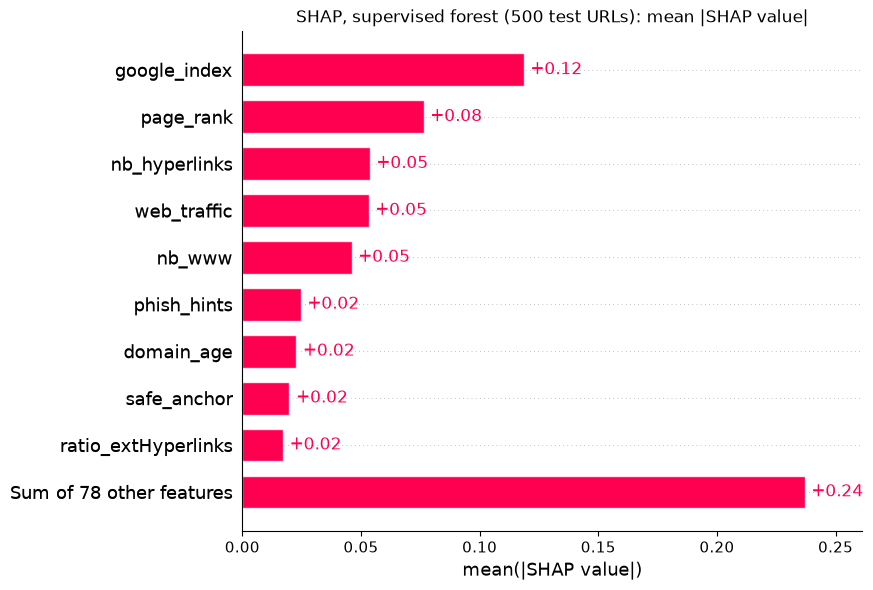

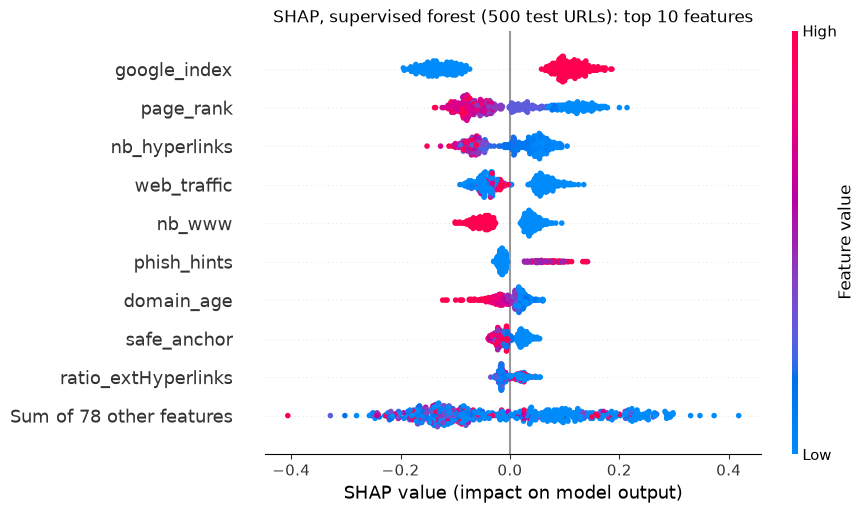

google_index            0.1186
page_rank               0.0764
nb_hyperlinks           0.0537
web_traffic             0.0532
nb_www                  0.0460
phish_hints             0.0246
domain_age              0.0227
safe_anchor             0.0199
ratio_extHyperlinks     0.0171
ratio_extRedirection    0.0142
dtype: float64


In [6]:
# STEP B2
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)
sv = explainer(X_test.iloc[:500])         # 500 test URLs is plenty
print(sv.values.shape)                    # (500, 87, 2) = URLs, features, classes
assert sv.values.shape == (500, 87, 2)
sv1 = sv[:, :, 1]                         # keep class 1 = phishing

shap.plots.bar(sv1, max_display=10, show=False)        # average push of each feature
plt.title("SHAP, supervised forest (500 test URLs): mean |SHAP value|")
plt.savefig("results/figures/B2_shap_forest_bar.png", dpi=150, bbox_inches="tight")
plt.show()
shap.plots.beeswarm(sv1, max_display=10, show=False)   # one dot per URL
plt.title("SHAP, supervised forest (500 test URLs): top 10 features")
plt.savefig("results/figures/B2_shap_forest_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

shap_top = pd.Series(np.abs(sv1.values).mean(axis=0),
                     index=X_test.columns).sort_values(ascending=False)
print(shap_top.head(10).round(4))
shap_top.rename("mean_abs_shap").rename_axis("feature").to_csv("results/tables/B2_shap_top.csv")

<!-- STEP B2 -->
**What we see**

- **The top feature is `google_index`, and its red dots are on the right.** Red = high value = 1 =
  Google has **not** indexed the page, and right = toward phishing. In plain words: "not indexed by
  Google" is the forest's strongest single reason to call a URL phishing, and "indexed" (blue, left)
  its strongest reason to call it legitimate.
- The next features read the same way: a **low** `page_rank` (blue) and **few** links (`nb_hyperlinks`,
  blue) push toward phishing, and a **low** `web_traffic` pushes toward phishing too, because 0 means
  "no traffic rank found" (81% of those URLs are phishing). More phishing words (`phish_hints`, red)
  push toward phishing; a young domain (`domain_age`, blue) slightly so.
- Three of the top four features (`google_index`, `page_rank`, `web_traffic`) are **external lookups**.
  Step C1 tests what happens without them.